<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/Day5_NLP_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from csv import field_size_limit
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

file_path ="/content/tweet_emotions.csv"
data = pd.read_csv(file_path)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
data

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...
...,...,...,...
39995,1753918954,neutral,@JohnLloydTaylor
39996,1753919001,love,Happy Mothers Day All my love
39997,1753919005,love,Happy Mother's Day to all the mommies out ther...
39998,1753919043,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [17]:
#Convert Text to Lowercase
data['clean_content'] = data['content'].str.lower()
print("Original text sample:")
print(data['content'].iloc[0])
print("\nConverted to lowercase sample:")
print(data['clean_content'].iloc[0])

Original text sample:
@tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[

Converted to lowercase sample:
@tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[


In [18]:
#Tokenization
data['tokenized_content'] = data['clean_content'].apply(word_tokenize)
print("Tokens for first 5 samples:")
for i in range(5):
    print(f"Sample {i+1}: {data['tokenized_content'].iloc[i]}")

Tokens for first 5 samples:
Sample 1: ['@', 'tiffanylue', 'i', 'know', 'i', 'was', 'listenin', 'to', 'bad', 'habit', 'earlier', 'and', 'i', 'started', 'freakin', 'at', 'his', 'part', '=', '[']
Sample 2: ['layin', 'n', 'bed', 'with', 'a', 'headache', 'ughhhh', '...', 'waitin', 'on', 'your', 'call', '...']
Sample 3: ['funeral', 'ceremony', '...', 'gloomy', 'friday', '...']
Sample 4: ['wants', 'to', 'hang', 'out', 'with', 'friends', 'soon', '!']
Sample 5: ['@', 'dannycastillo', 'we', 'want', 'to', 'trade', 'with', 'someone', 'who', 'has', 'houston', 'tickets', ',', 'but', 'no', 'one', 'will', '.']


In [19]:
#Stopword Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

print("Tokens before stopword removal (sample 1):")
print(data['tokenized_content'].iloc[0])
data['stopwords_removed'] = data['tokenized_content'].apply(remove_stopwords)
print("\nTokens after stopword removal (sample 1):")
print(data['stopwords_removed'].iloc[0])

Tokens before stopword removal (sample 1):
['@', 'tiffanylue', 'i', 'know', 'i', 'was', 'listenin', 'to', 'bad', 'habit', 'earlier', 'and', 'i', 'started', 'freakin', 'at', 'his', 'part', '=', '[']

Tokens after stopword removal (sample 1):
['@', 'tiffanylue', 'know', 'listenin', 'bad', 'habit', 'earlier', 'started', 'freakin', 'part', '=', '[']


In [20]:
#Stemming
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

print("Tokens before stemming (first 10 samples of processed tokens):")
for i in range(10):
    print(f"Sample {i+1}: {data['stopwords_removed'].iloc[i]}")

data['stemmed_content'] = data['stopwords_removed'].apply(apply_stemming)
print("\nTokens after stemming (first 10 samples):")
for i in range(10):
    print(f"Sample {i+1}: {data['stemmed_content'].iloc[i]}")

Tokens before stemming (first 10 samples of processed tokens):
Sample 1: ['@', 'tiffanylue', 'know', 'listenin', 'bad', 'habit', 'earlier', 'started', 'freakin', 'part', '=', '[']
Sample 2: ['layin', 'n', 'bed', 'headache', 'ughhhh', '...', 'waitin', 'call', '...']
Sample 3: ['funeral', 'ceremony', '...', 'gloomy', 'friday', '...']
Sample 4: ['wants', 'hang', 'friends', 'soon', '!']
Sample 5: ['@', 'dannycastillo', 'want', 'trade', 'someone', 'houston', 'tickets', ',', 'one', '.']
Sample 6: ['re-pinging', '@', 'ghostridah14', ':', "n't", 'go', 'prom', '?', 'bc', 'bf', "n't", 'like', 'friends']
Sample 7: ['sleep', ',', 'im', '!', 'thinking', 'old', 'friend', 'want', '.', "'s", 'married', '.', 'damn', ',', '&', 'amp', ';', 'wants', '2', '!', 'scandalous', '!']
Sample 8: ['hmmm', '.', 'http', ':', '//www.djhero.com/']
Sample 9: ['@', 'charviray', 'charlene', 'love', '.', 'miss']
Sample 10: ['@', 'kelcouch', "'m", 'sorry', 'least', "'s", 'friday', '?']

Tokens after stemming (first 10 samp

In [21]:
#Lemmatization
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

print("Tokens before lemmatization (first 10 samples of processed tokens):")
for i in range(10):
    print(f"Sample {i+1}: {data['stopwords_removed'].iloc[i]}")

data['lemmatized_content'] = data['stopwords_removed'].apply(apply_lemmatization)
print("\nTokens after lemmatization (first 10 samples):")
for i in range(10):
    print(f"Sample {i+1}: {data['lemmatized_content'].iloc[i]}")

print("\nComparison with Stemming (sample 1):")
print(f"Original tokens: {data['stopwords_removed'].iloc[0]}")
print(f"Stemmed: {data['stemmed_content'].iloc[0]}")

Tokens before lemmatization (first 10 samples of processed tokens):
Sample 1: ['@', 'tiffanylue', 'know', 'listenin', 'bad', 'habit', 'earlier', 'started', 'freakin', 'part', '=', '[']
Sample 2: ['layin', 'n', 'bed', 'headache', 'ughhhh', '...', 'waitin', 'call', '...']
Sample 3: ['funeral', 'ceremony', '...', 'gloomy', 'friday', '...']
Sample 4: ['wants', 'hang', 'friends', 'soon', '!']
Sample 5: ['@', 'dannycastillo', 'want', 'trade', 'someone', 'houston', 'tickets', ',', 'one', '.']
Sample 6: ['re-pinging', '@', 'ghostridah14', ':', "n't", 'go', 'prom', '?', 'bc', 'bf', "n't", 'like', 'friends']
Sample 7: ['sleep', ',', 'im', '!', 'thinking', 'old', 'friend', 'want', '.', "'s", 'married', '.', 'damn', ',', '&', 'amp', ';', 'wants', '2', '!', 'scandalous', '!']
Sample 8: ['hmmm', '.', 'http', ':', '//www.djhero.com/']
Sample 9: ['@', 'charviray', 'charlene', 'love', '.', 'miss']
Sample 10: ['@', 'kelcouch', "'m", 'sorry', 'least', "'s", 'friday', '?']

Tokens after lemmatization (fir

In [22]:
#Bag of words
from sklearn.feature_extraction.text import CountVectorizer

# Join the lemmatized tokens back into a string for vectorization
data['processed_text'] = data['lemmatized_content'].apply(lambda x: ' '.join(x))

vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(data['processed_text'])

print("Vocabulary (first 20 words):")
print(vectorizer_bow.vocabulary_)
print("\nFeature names (first 20 words):")
print(vectorizer_bow.get_feature_names_out()[:20])
print("\nMatrix shape:")
print(X_bow.shape)
print("\nSample of BoW matrix (first 5 rows, first 10 columns):")
print(X_bow.toarray()[:5, :10])

Vocabulary (first 20 words):
{'tiffanylue': 40964, 'know': 22969, 'listenin': 24357, 'bad': 4799, 'habit': 17556, 'earlier': 13097, 'started': 38443, 'freakin': 15662, 'part': 30860, 'layin': 23696, 'bed': 5340, 'headache': 18034, 'ughhhh': 42432, 'waitin': 43596, 'call': 7502, 'funeral': 15946, 'ceremony': 8139, 'gloomy': 16753, 'friday': 15774, 'want': 43678, 'hang': 17754, 'friend': 15780, 'soon': 37793, 'dannycastillo': 10879, 'trade': 41579, 'someone': 37731, 'houston': 18924, 'ticket': 40921, 'one': 30105, 're': 33458, 'pinging': 31633, 'ghostridah14': 16536, 'go': 16807, 'prom': 32601, 'bc': 5181, 'bf': 5643, 'like': 24144, 'sleep': 37261, 'im': 19523, 'thinking': 40739, 'old': 30008, 'married': 25868, 'damn': 10745, 'amp': 3227, 'scandalous': 35612, 'hmmm': 18572, 'http': 18984, 'www': 44876, 'djhero': 12235, 'com': 9435, 'charviray': 8360, 'charlene': 8317, 'love': 24855, 'miss': 27116, 'kelcouch': 22441, 'sorry': 37868, 'least': 23784, 'cant': 7647, 'fall': 14607, 'asleep': 4

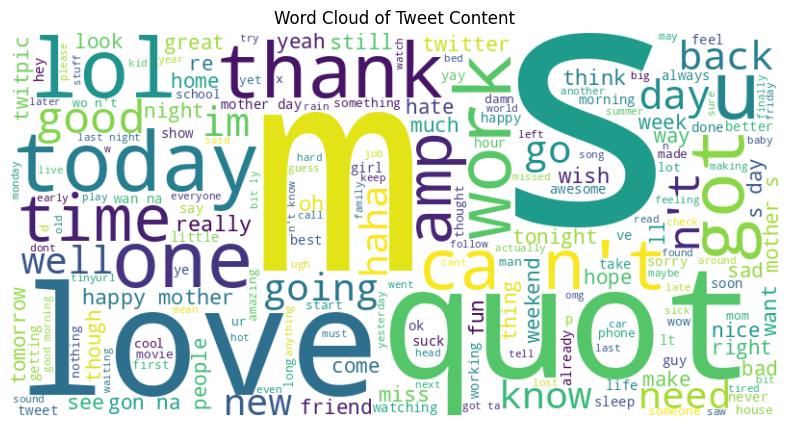

In [23]:
# Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all processed text into a single string
all_words = ' '.join(data['processed_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweet Content')
plt.show()

